# EDA on Motor Function

- MDS-UPDRS_Part_III_14Dec2025.csv
- MDS_UPDRS_Part_II__Patient_Questionnaire_14Dec2025.csv
- MDS-UPDRS_Part_I_14Dec2025.csv
- MDS-UPDRS_Part_I_Patient_Questionnaire_14Dec2025.csv
- MDS-UPDRS_Part_IV__Motor_Complications_14Dec2025.csv
- Modified_Schwab___England_Activities_of_Daily_Living_14Dec2025.csv
- Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_14Dec2025.csv
- Neuro_QoL__Upper_Extremity_Function_-_Short_Form_14Dec2025.csv
- Participant_Motor_Function_Questionnaire_14Dec2025.csv

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

# Allow pandas to show all columns
pd.set_option('display.max_columns', None)

In [2]:
# Load master_df
master_df = pd.read_csv('../../Experiment/preprocessing/master_df.csv')
print('master_df:', master_df.shape)

# Load all CSV data from motor function modality
motor_part_3_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_III_14Dec2025.csv')
motor_part_2_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS_UPDRS_Part_II__Patient_Questionnaire_14Dec2025.csv')
motor_part_1_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_I_14Dec2025.csv')
motor_part_1_patient_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_I_Patient_Questionnaire_14Dec2025.csv')
motor_part_4_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_IV__Motor_Complications_14Dec2025.csv')
schwab_and_eng_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/Modified_Schwab___England_Activities_of_Daily_Living_14Dec2025.csv')
nuero_qol_lower_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_14Dec2025.csv')
nuero_qol_upper_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/Neuro_QoL__Upper_Extremity_Function_-_Short_Form_14Dec2025.csv')
participant_motor_func_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/Participant_Motor_Function_Questionnaire_14Dec2025.csv')

print('motor_part_3_df:', motor_part_3_df.shape)
print('motor_part_2_df:', motor_part_2_df.shape)
print('motor_part_1_df:', motor_part_1_df.shape)
print('motor_part_1_patient_df:', motor_part_1_patient_df.shape)
print('motor_part_4_df:', motor_part_4_df.shape)
print('schwab_and_eng_df:', schwab_and_eng_df.shape)
print('nuero_qol_lower_df:', nuero_qol_lower_df.shape)
print('nuero_qol_upper_df:', nuero_qol_upper_df.shape)
print('participant_motor_func_df:', participant_motor_func_df.shape)

master_df: (4369, 5)


C:\Users\irovi\AppData\Local\Temp\ipykernel_57100\3720230829.py:6: DtypeWarning: Columns (16,21) have mixed types. Specify dtype option on import or set low_memory=False.
  motor_part_3_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_III_14Dec2025.csv')


motor_part_3_df: (35937, 65)
motor_part_2_df: (33035, 22)
motor_part_1_df: (30608, 15)
motor_part_1_patient_df: (33034, 16)
motor_part_4_df: (10358, 23)
schwab_and_eng_df: (29368, 8)
nuero_qol_lower_df: (11362, 15)
nuero_qol_upper_df: (11358, 15)
participant_motor_func_df: (10962, 19)


In [3]:
motor_part_3_df.columns.tolist()

['REC_ID',
 'PATNO',
 'EVENT_ID',
 'PAG_NAME',
 'INFODT',
 'PDTRTMNT',
 'PDSTATE',
 'HRPOSTMED',
 'HRDBSON',
 'HRDBSOFF',
 'PDMEDYN',
 'DBSYN',
 'ONOFFORDER',
 'OFFEXAM',
 'OFFNORSN',
 'DBSOFFYN',
 'DBSOFFTM',
 'ONEXAM',
 'ONNORSN',
 'HIFUYN',
 'DBSONYN',
 'DBSONTM',
 'PDMEDDT',
 'PDMEDTM',
 'EXAMDT',
 'EXAMTM',
 'NP3SPCH',
 'NP3FACXP',
 'NP3RIGN',
 'NP3RIGRU',
 'NP3RIGLU',
 'NP3RIGRL',
 'NP3RIGLL',
 'NP3FTAPR',
 'NP3FTAPL',
 'NP3HMOVR',
 'NP3HMOVL',
 'NP3PRSPR',
 'NP3PRSPL',
 'NP3TTAPR',
 'NP3TTAPL',
 'NP3LGAGR',
 'NP3LGAGL',
 'NP3RISNG',
 'NP3GAIT',
 'NP3FRZGT',
 'NP3PSTBL',
 'NP3POSTR',
 'NP3BRADY',
 'NP3PTRMR',
 'NP3PTRML',
 'NP3KTRMR',
 'NP3KTRML',
 'NP3RTARU',
 'NP3RTALU',
 'NP3RTARL',
 'NP3RTALL',
 'NP3RTALJ',
 'NP3RTCON',
 'NP3TOT',
 'DYSKPRES',
 'DYSKIRAT',
 'NHY',
 'ORIG_ENTRY',
 'LAST_UPDATE']

In [4]:
# motor_part_3_df['EVENT_ID'].unique()
motor_part_3_df.head(5)

,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,PDTRTMNT,PDSTATE,HRPOSTMED,HRDBSON,HRDBSOFF,PDMEDYN,DBSYN,ONOFFORDER,OFFEXAM,OFFNORSN,DBSOFFYN,DBSOFFTM,ONEXAM,ONNORSN,HIFUYN,DBSONYN,DBSONTM,PDMEDDT,PDMEDTM,EXAMDT,EXAMTM,NP3SPCH,NP3FACXP,NP3RIGN,NP3RIGRU,NP3RIGLU,NP3RIGRL,NP3RIGLL,NP3FTAPR,NP3FTAPL,NP3HMOVR,NP3HMOVL,NP3PRSPR,NP3PRSPL,NP3TTAPR,NP3TTAPL,NP3LGAGR,NP3LGAGL,NP3RISNG,NP3GAIT,NP3FRZGT,NP3PSTBL,NP3POSTR,NP3BRADY,NP3PTRMR,NP3PTRML,NP3KTRMR,NP3KTRML,NP3RTARU,NP3RTALU,NP3RTARL,NP3RTALL,NP3RTALJ,NP3RTCON,NP3TOT,DYSKPRES,DYSKIRAT,NHY,ORIG_ENTRY,LAST_UPDATE
0,272451901,3000,BL,NUPDRS3,02/2011,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02/2011,13:17:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,NaN,0.0,02/2011,2020-06-25 16:02:19
1,338703101,3000,V04,NUPDRS3,03/2012,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/2012,13:47:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,0.0,03/2012,2020-06-25 16:02:22
2,385009801,3000,V06,NUPDRS3,02/2013,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02/2013,12:22:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,NaN,0.0,02/2013,2020-06-25 16:02:22
3,437131401,3000,V08,NUPDRS3,03/2014,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/2014,13:22:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,NaN,0.0,05/2014,2020-06-25 16:02:22
4,512469901,3000,V10,NUPDRS3,03/2015,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/2015,11:43:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,NaN,0.0,03/2015,2020-06-25 16:02:23


Data shape after cleaning: (29261, 36)
Correlation with NP3TOT:
NP3TOT                1.000000
Score_Bradykinesia    0.933169
Score_Rigidity        0.829451
Score_Bulbar          0.769222
Score_PIGD            0.700249
Score_Tremor          0.628196
Name: NP3TOT, dtype: float64

Top 10 Influential Features for PD Stage (NHY):
     Feature  Importance
17  NP3BRADY    0.112042
1   NP3FACXP    0.066915
7   NP3FTAPR    0.060371
4   NP3RIGLU    0.055587
27  NP3RTCON    0.053973
3   NP3RIGRU    0.053195
8   NP3FTAPL    0.047704
12  NP3PRSPL    0.047364
31  NP3PSTBL    0.047129
13  NP3TTAPR    0.041481


C:\Users\irovi\AppData\Local\Temp\ipykernel_57100\1812730449.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature', ax=axes[1], palette='viridis')


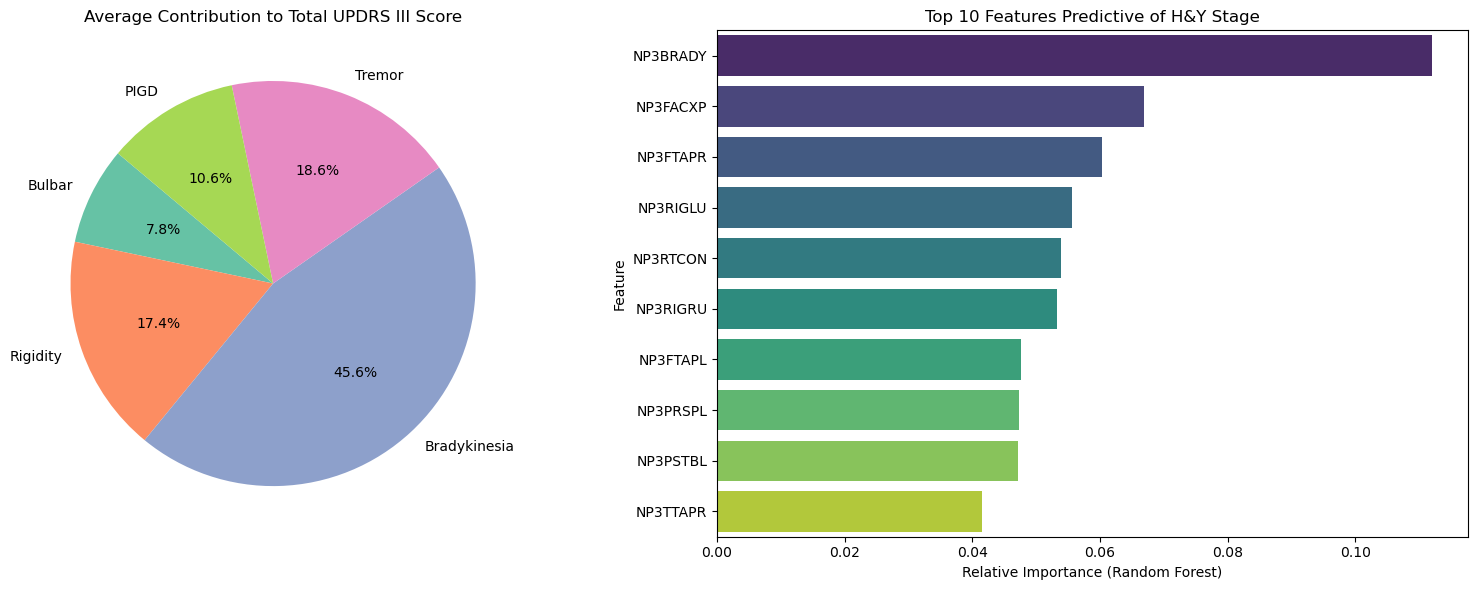

In [5]:
# Analysis for MDS-UPDRS Part III (Motor Examination)
# 1. Load Data
df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_III_14Dec2025.csv', low_memory=False)

# 2. Define Subcategories
subcats = {
    'Bulbar': ['NP3SPCH', 'NP3FACXP'],
    'Rigidity': ['NP3RIGN', 'NP3RIGRU', 'NP3RIGLU', 'NP3RIGRL', 'NP3RIGLL'],
    'Bradykinesia': ['NP3FTAPR', 'NP3FTAPL', 'NP3HMOVR', 'NP3HMOVL', 
                     'NP3PRSPR', 'NP3PRSPL', 'NP3TTAPR', 'NP3TTAPL', 
                     'NP3LGAGR', 'NP3LGAGL', 'NP3BRADY'],
    'Tremor': ['NP3PTRMR', 'NP3PTRML', 'NP3KTRMR', 'NP3KTRML', 
               'NP3RTARU', 'NP3RTALU', 'NP3RTARL', 'NP3RTALL', 
               'NP3RTALJ', 'NP3RTCON'],
    'PIGD': ['NP3RISNG', 'NP3GAIT', 'NP3FRZGT', 'NP3PSTBL', 'NP3POSTR']
}

all_feature_cols = [col for cat in subcats.values() for col in cat]

# 3. Robust Preprocessing
# Keep only relevant columns to avoid dtype issues with irrelevant ones
work_df = df[['PATNO', 'NHY', 'NP3TOT'] + all_feature_cols].copy()

# Coerce to numeric
for col in work_df.columns:
    work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

# Drop rows where Targets are missing
work_df = work_df.dropna(subset=['NP3TOT', 'NHY'])

# Fill missing feature values with 0 (Assuming missing sub-score ~ 0 or minor issue, or just to save data)
# Better: Use median
imputer = SimpleImputer(strategy='median')
work_df[all_feature_cols] = imputer.fit_transform(work_df[all_feature_cols])

print(f"Data shape after cleaning: {work_df.shape}")

# 4. Calculate Sub-Scores
for name, cols in subcats.items():
    work_df[f'Score_{name}'] = work_df[cols].sum(axis=1)

sub_score_cols = [f'Score_{name}' for name in subcats.keys()]

# 5. Correlation Analysis
corr_matrix = work_df[sub_score_cols + ['NP3TOT']].corr()
print("Correlation with NP3TOT:")
print(corr_matrix['NP3TOT'].sort_values(ascending=False))

# 6. Feature Importance (Predicting Stage)
X = work_df[all_feature_cols]
y = work_df['NHY'].astype(int).astype(str) # Convert to string classes '0', '1', '2'...

# Filter out rare classes if any (like Stage 5 might be rare) to avoid errors? RF handles it fine usually.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'Feature': all_feature_cols,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Influential Features for PD Stage (NHY):")
print(feature_importance.head(10))

# 7. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Contribution
avg_scores = work_df[sub_score_cols].mean()
axes[0].pie(avg_scores, labels=[c.replace('Score_', '') for c in avg_scores.index], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
axes[0].set_title('Average Contribution to Total UPDRS III Score')

# Plot B: Feature Importance
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature', ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Features Predictive of H&Y Stage')
axes[1].set_xlabel('Relative Importance (Random Forest)')

plt.tight_layout()
# plt.savefig('updrs_influence_analysis.png')

Correlation with NP2PTOT:
NP2PTOT            1.000000
Score_FineMotor    0.934516
Score_Mobility     0.870346
Score_Bulbar       0.791844
Score_Tremor       0.545382
Name: NP2PTOT, dtype: float64

Top 10 Influential Features for Part II Score:
    Feature  Importance
4   NP2DRES    0.530345
7   NP2HOBB    0.112977
6   NP2HWRT    0.091369
9   NP2RISE    0.085121
0   NP2SPCH    0.040198
10  NP2WALK    0.033859
1   NP2SALV    0.032187
11  NP2FREZ    0.018064
12  NP2TRMR    0.015408
3    NP2EAT    0.012424


C:\Users\irovi\AppData\Local\Temp\ipykernel_57100\842474695.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature', ax=axes[1], palette='viridis')


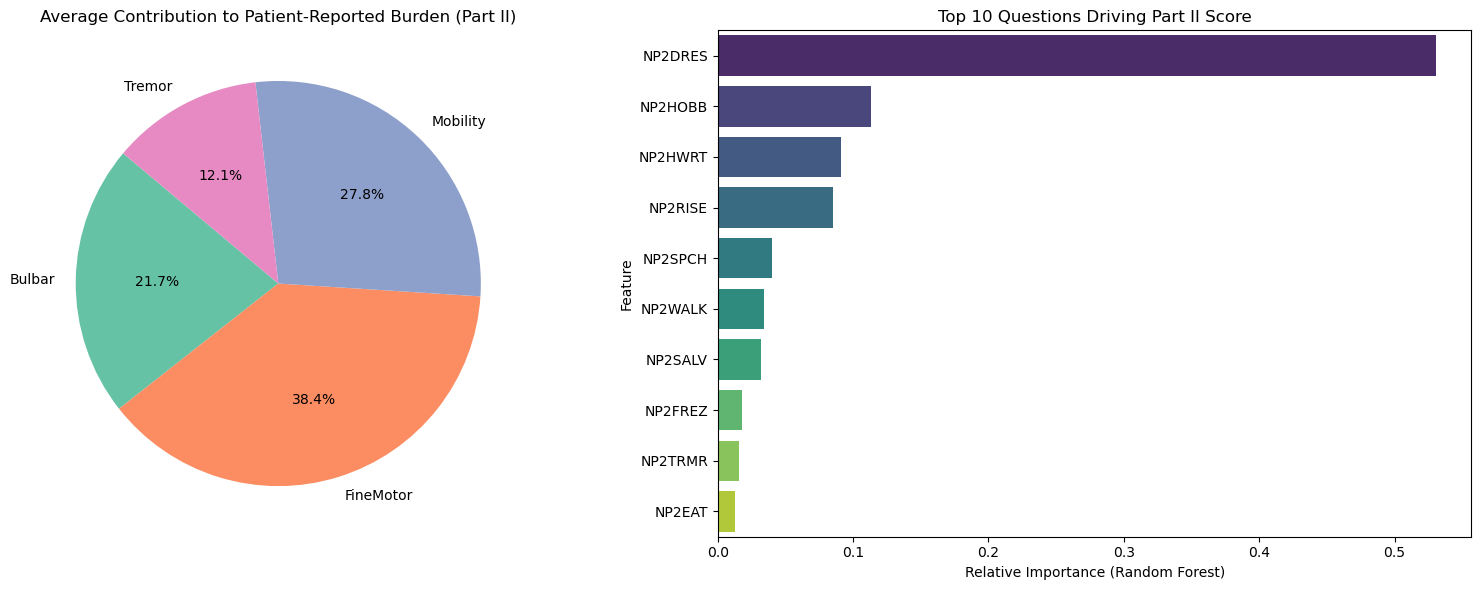

In [6]:
# Analysis for MDS-UPDRS Part II (Patient Questionnaire)
# 1. Load Data
df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS_UPDRS_Part_II__Patient_Questionnaire_14Dec2025.csv')

# 2. Define Subcategories
subcats = {
    'Bulbar': ['NP2SPCH', 'NP2SALV', 'NP2SWAL'],
    'FineMotor': ['NP2EAT', 'NP2DRES', 'NP2HYGN', 'NP2HWRT', 'NP2HOBB'],
    'Mobility': ['NP2TURN', 'NP2RISE', 'NP2WALK', 'NP2FREZ'],
    'Tremor': ['NP2TRMR']
}

all_feature_cols = [col for cat in subcats.values() for col in cat]

# 3. Preprocessing
# Keep relevant columns
work_df = df[['PATNO', 'NP2PTOT'] + all_feature_cols].copy()

# Coerce to numeric
for col in work_df.columns:
    work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

# Drop rows where Target is missing
work_df = work_df.dropna(subset=['NP2PTOT'])

# Handle missing features (if any)
imputer = SimpleImputer(strategy='median')
work_df[all_feature_cols] = imputer.fit_transform(work_df[all_feature_cols])

# 4. Calculate Sub-Scores
for name, cols in subcats.items():
    work_df[f'Score_{name}'] = work_df[cols].sum(axis=1)

sub_score_cols = [f'Score_{name}' for name in subcats.keys()]

# 5. Correlation Analysis
corr_matrix = work_df[sub_score_cols + ['NP2PTOT']].corr()
print("Correlation with NP2PTOT:")
print(corr_matrix['NP2PTOT'].sort_values(ascending=False))

# 6. Feature Importance
X = work_df[all_feature_cols]
y = work_df['NP2PTOT']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'Feature': all_feature_cols,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Influential Features for Part II Score:")
print(feature_importance.head(10))

# 7. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Average Contribution
avg_scores = work_df[sub_score_cols].mean()
axes[0].pie(avg_scores, labels=[c.replace('Score_', '') for c in avg_scores.index], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
axes[0].set_title('Average Contribution to Patient-Reported Burden (Part II)')

# Plot B: Feature Importance
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature', ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Questions Driving Part II Score')
axes[1].set_xlabel('Relative Importance (Random Forest)')

plt.tight_layout()
# plt.savefig('updrs_part2_analysis.png')

Correlation with NP1RTOT:
NP1RTOT                      1.000000
Score_Mood_Apathy            0.923674
Score_Cognitive_Psychosis    0.753148
Name: NP1RTOT, dtype: float64

Top Features influencing Part I Score:
   Feature  Importance
3  NP1DPRS    0.441629
5  NP1APAT    0.193913
0   NP1COG    0.175298
4  NP1ANXS    0.144933
1  NP1HALL    0.025687
2   NP1DDS    0.018540


C:\Users\irovi\AppData\Local\Temp\ipykernel_57100\1091221548.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', ax=axes[1], palette='viridis')


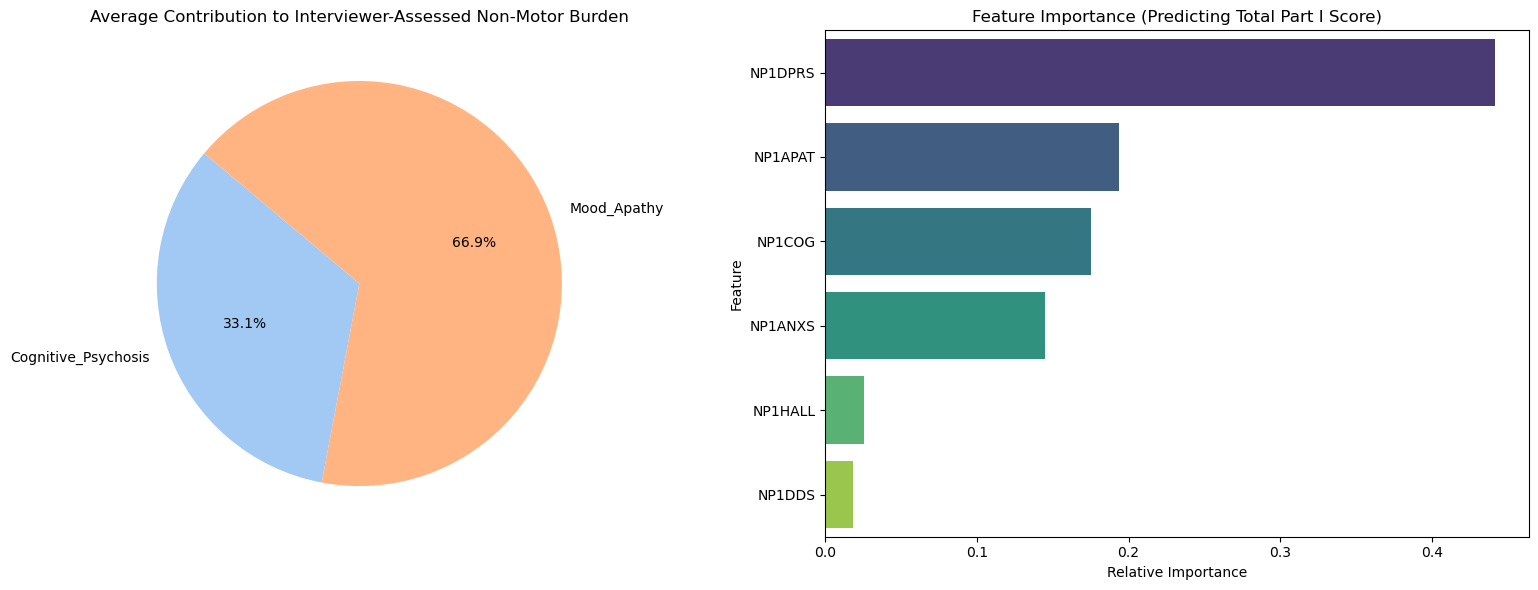

In [10]:
# Analysis for MDS-UPDRS Part I
# 1. Load Part I Data
df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_I_14Dec2025.csv', low_memory=False)

# 2. Define Subcategories
# Based on columns inside THIS file only: NP1COG, NP1HALL, NP1DPRS, NP1ANXS, NP1APAT, NP1DDS
subcats = {
    'Cognitive_Psychosis': ['NP1COG', 'NP1HALL', 'NP1DDS'],
    'Mood_Apathy': ['NP1DPRS', 'NP1ANXS', 'NP1APAT']
}
all_features = [col for cat in subcats.values() for col in cat]

# 3. Preprocessing
# Select columns
work_df = df[['PATNO', 'NP1RTOT'] + all_features].copy()

# Coerce to numeric
for col in work_df.columns:
    work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

# Drop rows where Total Score is missing
work_df = work_df.dropna(subset=['NP1RTOT'])

# Impute features
imputer = SimpleImputer(strategy='median')
work_df[all_features] = imputer.fit_transform(work_df[all_features])

# 4. Calculate Sub-Scores
for name, cols in subcats.items():
    work_df[f'Score_{name}'] = work_df[cols].sum(axis=1)

sub_score_cols = [f'Score_{name}' for name in subcats.keys()]

# 5. Correlation Analysis
corr_matrix = work_df[sub_score_cols + ['NP1RTOT']].corr()
print("Correlation with NP1RTOT:")
print(corr_matrix['NP1RTOT'].sort_values(ascending=False))

# 6. Feature Importance (Predicting Total Score)
X = work_df[all_features]
y = work_df['NP1RTOT']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop Features influencing Part I Score:")
print(feature_importance)

# 7. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Contribution
avg_scores = work_df[sub_score_cols].mean()
axes[0].pie(avg_scores, labels=[c.replace('Score_', '') for c in avg_scores.index], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[0].set_title('Average Contribution to Interviewer-Assessed Non-Motor Burden')

# Plot B: Feature Importance
sns.barplot(data=feature_importance, x='Importance', y='Feature', ax=axes[1], palette='viridis')
axes[1].set_title('Feature Importance (Predicting Total Part I Score)')
axes[1].set_xlabel('Relative Importance')

plt.tight_layout()
# plt.savefig('updrs_part1_ia_analysis.png')

Correlation with NP1PTOT:
NP1PTOT                  1.000000
Score_Sensory_Fatigue    0.807501
Score_Autonomic          0.799338
Score_Sleep              0.787977
Name: NP1PTOT, dtype: float64

Top Influential Features for Part IB Total Score:
   Feature  Importance
6  NP1FATG    0.452036
0  NP1SLPN    0.183462
2  NP1URIN    0.118349
5  NP1PAIN    0.088163
1  NP1SLPD    0.059104
3  NP1CNST    0.054424
4  NP1LTHD    0.044463


C:\Users\irovi\AppData\Local\Temp\ipykernel_57100\3299279871.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', ax=axes[1], palette='viridis')


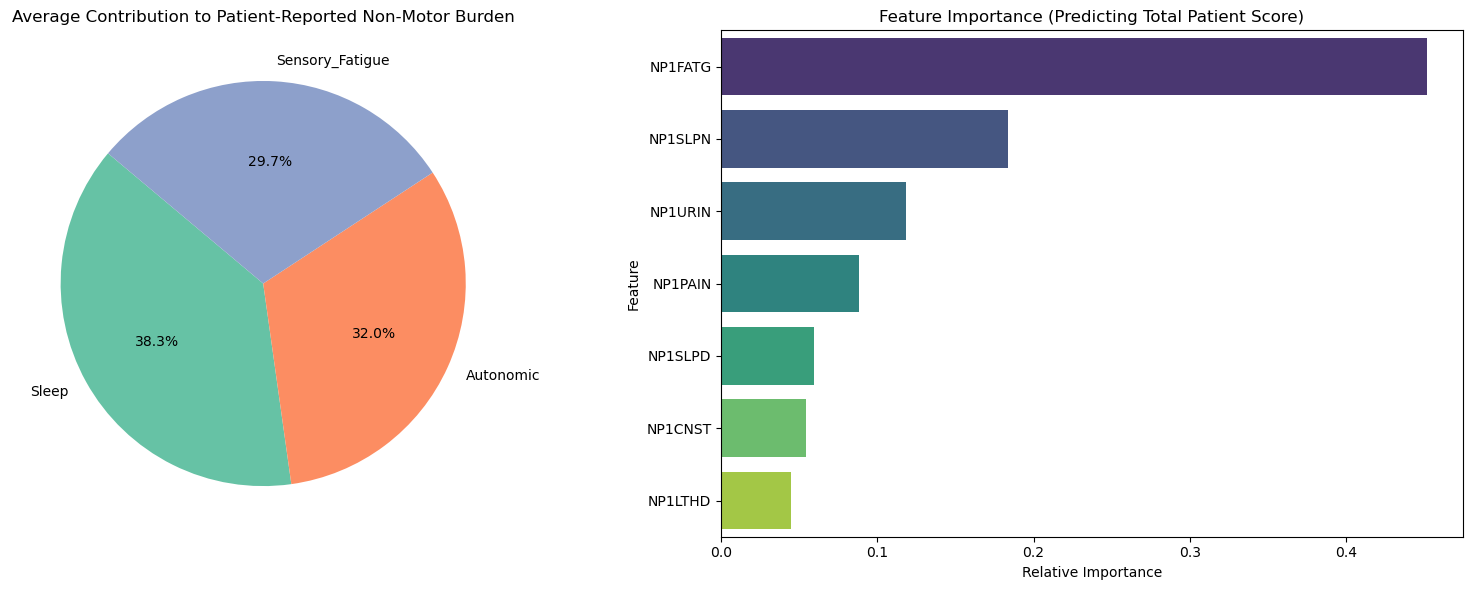

In [11]:
# Analysis for MDS-UPDRS Part IB (Patient Questionnaire)
# 1. Load Data
df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_I_Patient_Questionnaire_14Dec2025.csv', low_memory=False)

# 2. Inspect and Define Subcategories
# Standard Part IB columns typically found:
# NP1SLPN (Sleep), NP1SLPD (Daytime Sleepiness), NP1PAIN (Pain), 
# NP1URIN (Urinary), NP1CNST (Constipation), NP1LTHD (Lightheadedness), NP1FATG (Fatigue)

subcats = {
    'Sleep': ['NP1SLPN', 'NP1SLPD'],
    'Autonomic': ['NP1URIN', 'NP1CNST', 'NP1LTHD'],
    'Sensory_Fatigue': ['NP1PAIN', 'NP1FATG']
}

all_feature_cols = [col for cat in subcats.values() for col in cat]

# Check which columns are actually in the dataframe
valid_features = [c for c in all_feature_cols if c in df.columns]

# 3. Preprocessing
work_df = df[['PATNO', 'NP1PTOT'] + valid_features].copy()

# Coerce to numeric
for col in work_df.columns:
    work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

# Drop rows where Target is missing
work_df = work_df.dropna(subset=['NP1PTOT'])

# Impute missing features
imputer = SimpleImputer(strategy='median')
work_df[valid_features] = imputer.fit_transform(work_df[valid_features])

# 4. Calculate Sub-Scores
for name, cols in subcats.items():
    # Only sum columns that exist
    actual_cols = [c for c in cols if c in valid_features]
    if actual_cols:
        work_df[f'Score_{name}'] = work_df[actual_cols].sum(axis=1)

sub_score_cols = [c for c in work_df.columns if c.startswith('Score_')]

# 5. Correlation Analysis
corr_matrix = work_df[sub_score_cols + ['NP1PTOT']].corr()
print("Correlation with NP1PTOT:")
print(corr_matrix['NP1PTOT'].sort_values(ascending=False))

# 6. Feature Importance
X = work_df[valid_features]
y = work_df['NP1PTOT']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'Feature': valid_features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop Influential Features for Part IB Total Score:")
print(feature_importance)

# 7. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Contribution
avg_scores = work_df[sub_score_cols].mean()
axes[0].pie(avg_scores, labels=[c.replace('Score_', '') for c in avg_scores.index], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
axes[0].set_title('Average Contribution to Patient-Reported Non-Motor Burden')

# Plot B: Feature Importance
sns.barplot(data=feature_importance, x='Importance', y='Feature', ax=axes[1], palette='viridis')
axes[1].set_title('Feature Importance (Predicting Total Patient Score)')
axes[1].set_xlabel('Relative Importance')

plt.tight_layout()
# plt.savefig('updrs_part1_patient_analysis.png')

Correlation with NP4TOT:
NP4TOT                1.000000
Score_Fluctuations    0.925170
Score_Dyskinesias     0.683091
Score_Dystonia        0.597813
Name: NP4TOT, dtype: float64

Top Features influencing Part IV Score:
    Feature  Importance
3  NP4FLCTI    0.745150
1  NP4DYSKI    0.063002
5  NP4DYSTN    0.059031
2    NP4OFF    0.059024
0  NP4WDYSK    0.045306
4  NP4FLCTX    0.028487


C:\Users\irovi\AppData\Local\Temp\ipykernel_57100\2398544285.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', ax=axes[1], palette='viridis')


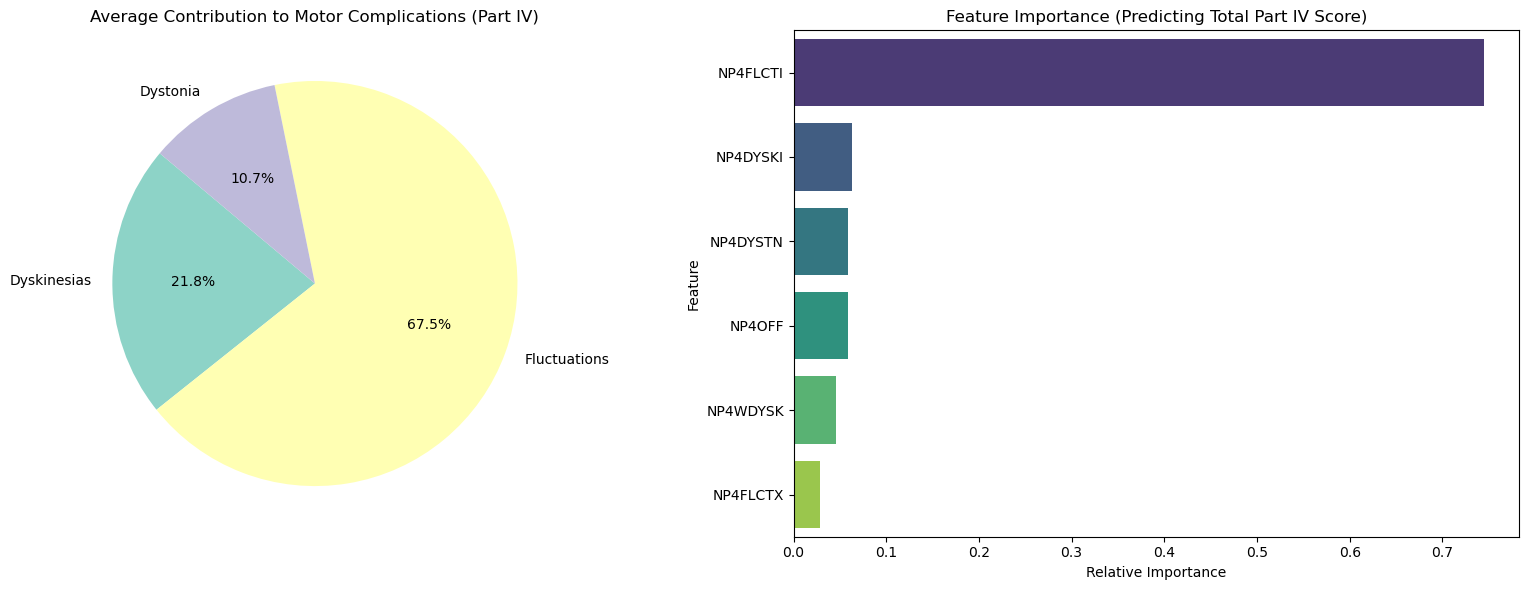

In [13]:
# Analysis for MDS-UPDRS Part IV (Motor Complications)
# 1. Load Part IV Data
df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_IV__Motor_Complications_14Dec2025.csv', low_memory=False)

# 2. Define Subcategories based on clinical domains
# Dyskinesias: 4.1 Time, 4.2 Impact
dyskinesia_cols = ['NP4WDYSK', 'NP4DYSKI']

# Fluctuations (OFF Time): 4.3 Time, 4.4 Impact, 4.5 Complexity
fluctuation_cols = ['NP4OFF', 'NP4FLCTI', 'NP4FLCTX']

# Dystonia: 4.6 Painful Dystonia
dystonia_cols = ['NP4DYSTN']

subcats = {
    'Dyskinesias': dyskinesia_cols,
    'Fluctuations': fluctuation_cols,
    'Dystonia': dystonia_cols
}

all_features = dyskinesia_cols + fluctuation_cols + dystonia_cols

# 3. Preprocessing
# Select columns
work_df = df[['PATNO', 'NP4TOT'] + all_features].copy()

# Coerce to numeric
for col in work_df.columns:
    work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

# Drop rows where Total Score is missing
work_df = work_df.dropna(subset=['NP4TOT'])

# Part IV is often 0 for early patients. Fill NaN with 0?
# Or Median. Let's inspect missingness.
# If mostly missing, it implies 0 (no complications). But let's be safe and use 0 fill for this specific part 
# because "NaN" often means "No complications to report" in clinical data entry for Part IV.
work_df[all_features] = work_df[all_features].fillna(0)

# 4. Calculate Sub-Scores
for name, cols in subcats.items():
    work_df[f'Score_{name}'] = work_df[cols].sum(axis=1)

sub_score_cols = [f'Score_{name}' for name in subcats.keys()]

# 5. Correlation Analysis
corr_matrix = work_df[sub_score_cols + ['NP4TOT']].corr()
print("Correlation with NP4TOT:")
print(corr_matrix['NP4TOT'].sort_values(ascending=False))

# 6. Feature Importance (Predicting Total Score)
X = work_df[all_features]
y = work_df['NP4TOT']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop Features influencing Part IV Score:")
print(feature_importance)

# 7. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Contribution
avg_scores = work_df[sub_score_cols].mean()
# Handle case where all are 0 (early PD)
if avg_scores.sum() == 0:
    print("Warning: All average scores are 0. Skipping Pie Chart.")
    axes[0].text(0.5, 0.5, "No Motor Complications Recorded (All 0)", ha='center')
else:
    axes[0].pie(avg_scores, labels=[c.replace('Score_', '') for c in avg_scores.index], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set3'))
    axes[0].set_title('Average Contribution to Motor Complications (Part IV)')

# Plot B: Feature Importance
sns.barplot(data=feature_importance, x='Importance', y='Feature', ax=axes[1], palette='viridis')
axes[1].set_title('Feature Importance (Predicting Total Part IV Score)')
axes[1].set_xlabel('Relative Importance')

plt.tight_layout()
# plt.savefig('updrs_part4_analysis.png')